,PERIODO,NUMERO DE EVENTOS
0,2018-10-01,72213
1,2018-11-01,70786
2,2018-12-01,71236
3,2019-01-01,56359
4,2019-02-01,60711
5,2019-03-01,41858
6,2019-04-01,55694
7,2019-05-01,73670
8,2019-06-01,77005
9,2019-07-01,68811


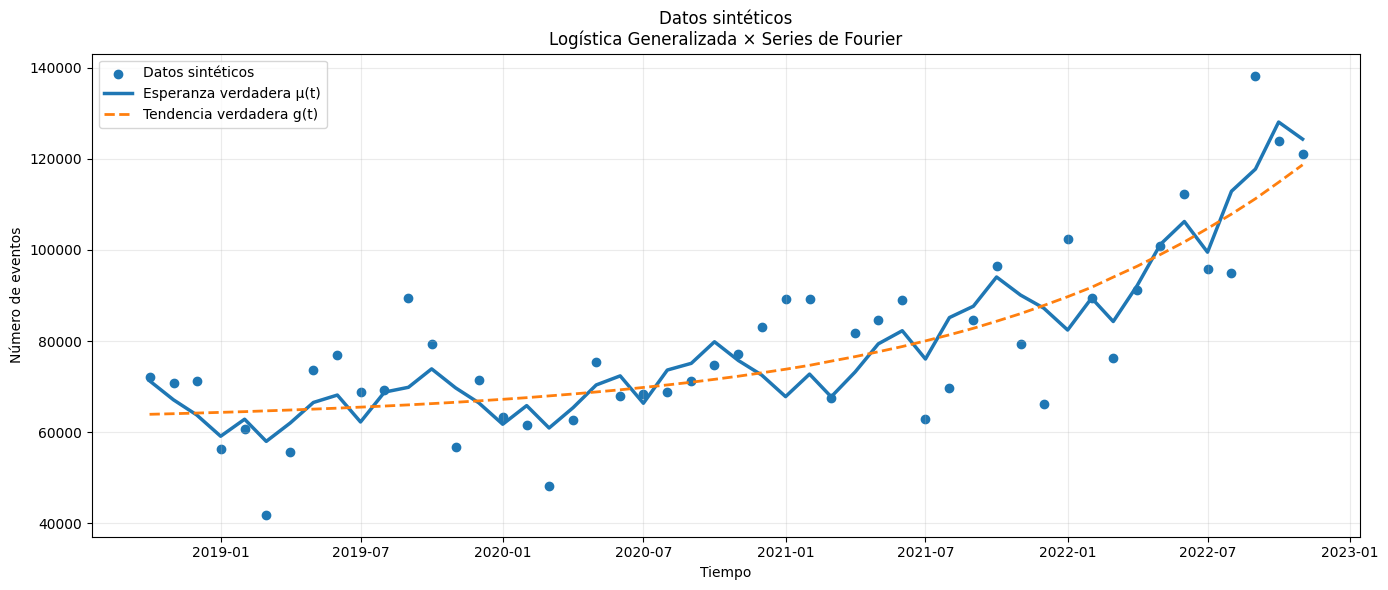

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SEMILLA
# ============================================================

SEED = 123
rng = np.random.default_rng(SEED)


# ============================================================
# CANTIDAD DE DATOS HISTÓRICOS
# ============================================================

N_MESES = 50

fechas = pd.date_range(
    start="2018-10-01",
    periods=N_MESES,
    freq="MS"
)

t = np.arange(N_MESES, dtype=float)


# ============================================================
# PARÁMETROS VERDADEROS
# TENDENCIA LOGÍSTICA GENERALIZADA / RICHARDS
# ============================================================

L = 60_000.0
K = 350_000.0

A = 20.0
nu = 0.90

theta0 = -0.8569251243558412
theta1 = 0.0300555798
theta2 = 0.000505379458


# ============================================================
# z(t)
# ============================================================

z = (
    theta0
    + theta1 * t
    + theta2 * t**2
)


# ============================================================
# COMPONENTE TENDENCIAL g(t)
# ============================================================

g = (
    L
    + (K - L)
    /
    (
        1.0
        + A * np.exp(-z)
    )**(1.0 / nu)
)


# ============================================================
# PERÍODOS ESTACIONALES
# ============================================================

periodos = np.array([
    2.0,
    3.0,
    4.0,
    6.0,
    12.0
])


# ============================================================
# COEFICIENTES FOURIER VERDADEROS
# ============================================================

a = np.array([
     0.020,   # P = 2
    -0.018,   # P = 3
     0.022,   # P = 4
     0.030,   # P = 6
     0.055    # P = 12
])

b = np.array([
    -0.010,   # P = 2
     0.015,   # P = 3
    -0.018,   # P = 4
     0.020,   # P = 6
    -0.035    # P = 12
])


# ============================================================
# COMPONENTE ESTACIONAL s(t)
# ============================================================

s = np.zeros_like(t)

for P, aj, bj in zip(periodos, a, b):

    s += (
        aj * np.cos(2.0 * np.pi * t / P)
        +
        bj * np.sin(2.0 * np.pi * t / P)
    )


# ============================================================
# ESPERANZA TOTAL
#
# mu(t) = g(t) * exp(s(t))
# ============================================================

mu = g * np.exp(s)


# ============================================================
# GENERADOR EXACTO DE POISSON GENERALIZADA
#
# P(X=x) =
# lambda * (lambda + rho*x)^(x-1) / x!
# * exp(-(lambda + rho*x))
#
# lambda = mu * (1-rho)
#
# Válido aquí para:
# 0 <= rho < 1
# ============================================================

def poisson_generalizada(mu, rho, rng):

    lambda_ = mu * (1.0 - rho)

    # Número inicial de eventos
    activos = int(rng.poisson(lambda_))

    total = activos

    # Representación mediante proceso de ramificación
    while activos > 0:

        activos = int(
            rng.poisson(rho * activos)
        )

        total += activos

    return total


# ============================================================
# DISPERSIÓN
#
# rho alto -> bastante variabilidad alrededor de la media
# ============================================================

rho = 0.97


# ============================================================
# GENERAR OBSERVACIONES
# ============================================================

y = np.array([
    poisson_generalizada(
        mu=m,
        rho=rho,
        rng=rng
    )
    for m in mu
])


# ============================================================
# DATAFRAME FINAL
# ============================================================

df = pd.DataFrame({

    "PERIODO": fechas,

    "NUMERO DE EVENTOS": y

})


# ============================================================
# MOSTRAR DATAFRAME
# ============================================================

display(df)


# ============================================================
# PLOT DE LOS DATOS GENERADOS
# ============================================================

plt.figure(figsize=(14, 6))

plt.scatter(
    df["PERIODO"],
    df["NUMERO DE EVENTOS"],
    label="Datos sintéticos"
)

plt.plot(
    df["PERIODO"],
    mu,
    linewidth=2.5,
    label="Esperanza verdadera μ(t)"
)

plt.plot(
    df["PERIODO"],
    g,
    linestyle="--",
    linewidth=2,
    label="Tendencia verdadera g(t)"
)

plt.xlabel("Tiempo")
plt.ylabel("Número de eventos")

plt.title(
    "Datos sintéticos\n"
    "Logística Generalizada × Series de Fourier"
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.show()

,PERIODO,NUMERO DE EVENTOS
0,2021-10-01,470606
1,2021-11-01,461065
2,2021-12-01,403610
3,2022-01-01,370439
4,2022-02-01,378739
5,2022-03-01,372409
6,2022-04-01,423002
7,2022-05-01,400253
8,2022-06-01,399311
9,2022-07-01,382835


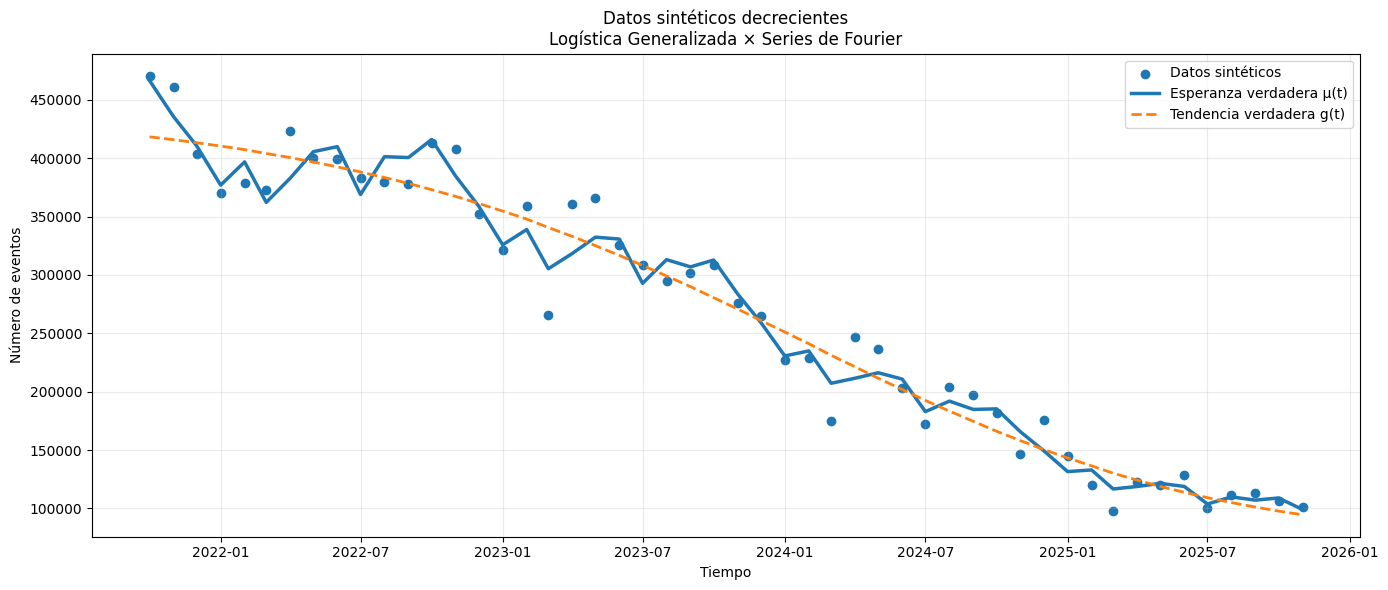


PARÁMETROS VERDADEROS
L       = 70000.0
K       = 450000.0
A       = 20.0
nu      = 0.9
theta0  = 5.5
theta1  = -0.08
theta2  = -0.0004
rho     = 0.97

Períodos:
[ 2.  3.  4.  6. 12.]

a:
[ 0.02  -0.018  0.022  0.03   0.055]

b:
[-0.01   0.015 -0.018  0.02  -0.035]


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SEMILLA
# ============================================================

SEED = 123
rng = np.random.default_rng(SEED)


# ============================================================
# CANTIDAD DE DATOS HISTÓRICOS
# ============================================================

N_MESES = 50

fechas = pd.date_range(
    start="2021-10-01",
    periods=N_MESES,
    freq="MS"
)

t = np.arange(N_MESES, dtype=float)


# ============================================================
# PARÁMETROS VERDADEROS
# TENDENCIA LOGÍSTICA GENERALIZADA / RICHARDS
#
# AHORA:
# parte desde un valor alto
# y converge hacia L
# ============================================================

L = 70_000.0
K = 450_000.0

A = 20.0
nu = 0.90


# ------------------------------------------------------------
# z(t) decreciente
#
# Como g(t) aumenta con z(t),
# hacemos que z(t) disminuya para que g(t) disminuya.
#
# theta1 < 0
# theta2 < 0
# ------------------------------------------------------------

theta0 = 5.50
theta1 = -0.080
theta2 = -0.00040


# ============================================================
# z(t)
# ============================================================

z = (
    theta0
    + theta1 * t
    + theta2 * t**2
)


# ============================================================
# COMPONENTE TENDENCIAL g(t)
# ============================================================

g = (
    L
    + (K - L)
    /
    (
        1.0
        + A * np.exp(-z)
    )**(1.0 / nu)
)


# ============================================================
# PERÍODOS ESTACIONALES
# ============================================================

periodos = np.array([
    2.0,
    3.0,
    4.0,
    6.0,
    12.0
])


# ============================================================
# COEFICIENTES FOURIER VERDADEROS
# ============================================================

a = np.array([
     0.020,   # P = 2
    -0.018,   # P = 3
     0.022,   # P = 4
     0.030,   # P = 6
     0.055    # P = 12
])

b = np.array([
    -0.010,   # P = 2
     0.015,   # P = 3
    -0.018,   # P = 4
     0.020,   # P = 6
    -0.035    # P = 12
])


# ============================================================
# COMPONENTE ESTACIONAL s(t)
# ============================================================

s = np.zeros_like(t)

for P, aj, bj in zip(periodos, a, b):

    s += (
        aj * np.cos(2.0 * np.pi * t / P)
        +
        bj * np.sin(2.0 * np.pi * t / P)
    )


# ============================================================
# ESPERANZA TOTAL
#
# mu(t) = g(t) * exp(s(t))
#
# Como g(t) disminuye,
# la amplitud absoluta de las oscilaciones también disminuye.
# ============================================================

mu = g * np.exp(s)


# ============================================================
# GENERADOR DE POISSON GENERALIZADA
#
# lambda = mu * (1-rho)
#
# Válido para:
# 0 <= rho < 1
# ============================================================

def poisson_generalizada(mu, rho, rng):

    lambda_ = mu * (1.0 - rho)

    # Número inicial de eventos
    activos = int(
        rng.poisson(lambda_)
    )

    total = activos

    # Representación mediante proceso de ramificación
    while activos > 0:

        activos = int(
            rng.poisson(
                rho * activos
            )
        )

        total += activos

    return total


# ============================================================
# DISPERSIÓN
# ============================================================

rho = 0.97


# ============================================================
# GENERAR OBSERVACIONES
# ============================================================

y = np.array([

    poisson_generalizada(
        mu=m,
        rho=rho,
        rng=rng
    )

    for m in mu

])


# ============================================================
# DATAFRAME FINAL
# ============================================================

df = pd.DataFrame({

    "PERIODO": fechas,

    "NUMERO DE EVENTOS": y

})


# ============================================================
# MOSTRAR DATAFRAME
# ============================================================

display(df)


# ============================================================
# PLOT DE LOS DATOS GENERADOS
# ============================================================

plt.figure(
    figsize=(14, 6)
)


# Datos observados
plt.scatter(
    df["PERIODO"],
    df["NUMERO DE EVENTOS"],
    label="Datos sintéticos"
)


# Esperanza verdadera
plt.plot(
    df["PERIODO"],
    mu,
    linewidth=2.5,
    label="Esperanza verdadera μ(t)"
)


# Tendencia Richards
plt.plot(
    df["PERIODO"],
    g,
    linestyle="--",
    linewidth=2,
    label="Tendencia verdadera g(t)"
)


plt.xlabel("Tiempo")

plt.ylabel(
    "Número de eventos"
)

plt.title(
    "Datos sintéticos decrecientes\n"
    "Logística Generalizada × Series de Fourier"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# MOSTRAR PARÁMETROS VERDADEROS
# ============================================================

print("\n" + "=" * 60)
print("PARÁMETROS VERDADEROS")
print("=" * 60)

print(f"L       = {L}")
print(f"K       = {K}")
print(f"A       = {A}")
print(f"nu      = {nu}")

print(f"theta0  = {theta0}")
print(f"theta1  = {theta1}")
print(f"theta2  = {theta2}")

print(f"rho     = {rho}")

print("\nPeríodos:")
print(periodos)

print("\na:")
print(a)

print("\nb:")
print(b)

print("=" * 60)

In [30]:
# ============================================================
# MODELO:
# LOGÍSTICA GENERALIZADA × FOURIER
# DISTRIBUCIÓN DE POISSON GENERALIZADA
# OPTIMIZACIÓN CON TENSORFLOW + XLA + BLOQUES GPU
#
# Requiere que exista:
#
# df["PERIODO"]
# df["NUMERO DE EVENTOS"]
#
# ============================================================

import math
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.special import gammaln


# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

tf.keras.backend.set_floatx("float64")

DTYPE = tf.float64


# ------------------------------------------------------------
# ENTRENAMIENTO
# ------------------------------------------------------------

EPOCHS = 700000

LEARNING_RATE = tf.keras.optimizers.schedules.ExponentialDecay(

    initial_learning_rate=0.0001,

    decay_steps=EPOCHS,

    decay_rate=0.001,

    staircase=False
)

# Weight decay desacoplado del optimizador AdamW.
# Se aplica a TODAS las variables incluidas en `variables`, incluido rho.
WEIGHT_DECAY = 0#1e-4

LAMBDA_RIDGE = 0.001#1e-4

PRINT_EVERY = 100

# Número de actualizaciones de AdamW ejecutadas dentro de una sola
# llamada al grafo compilado. Como PRINT_EVERY=100, Python vuelve
# a intervenir solo una vez cada 100 actualizaciones.
TRAIN_BLOCK_SIZE = PRINT_EVERY

# XLA compila el bloque completo de entrenamiento para reducir
# overhead Python/CPU y fusiones innecesarias de kernels en GPU.
USE_XLA = True

# Diferencia mínima para considerar que una solución es mejor.
BEST_MIN_DELTA = tf.constant(1e-9, dtype=DTYPE)


# ------------------------------------------------------------
# PERÍODOS FOURIER FIJOS
#
# No son parámetros entrenables.
#
# Unidades: meses
# ------------------------------------------------------------

P1_FIXED = 2.0
P2_FIXED = 3.0
P3_FIXED = 4.0
P4_FIXED = 6.0
P5_FIXED = 12.0


# ------------------------------------------------------------
# POISSON GENERALIZADA
#
# rho es un parámetro ENTRENABLE y DIRECTO.
# No se restringe su signo mediante reparametrización.
#
# rho = 0  -> Poisson
# rho > 0  -> sobredispersión
# rho < 0  -> subdispersión
#
# El valor siguiente es SOLO la inicialización.
# ------------------------------------------------------------

rho_init = 0.995


# ------------------------------------------------------------
# Penalización para impedir combinaciones fuera del soporte
#
# Si rho < 0 debe cumplirse:
#
# lambda_t + rho*y_t > 0
# ------------------------------------------------------------

SUPPORT_PENALTY = 1e3

EPS = tf.constant(
    1e-12,
    dtype=DTYPE
)


# ============================================================
# 2. PREPARAR DATOS
# ============================================================

data = df.copy()

data["PERIODO"] = pd.to_datetime(
    data["PERIODO"]
)

data = (
    data
    .sort_values("PERIODO")
    .dropna(
        subset=[
            "PERIODO",
            "NUMERO DE EVENTOS"
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Comprobar que NUMERO DE EVENTOS sea un conteo no negativo
# ------------------------------------------------------------

if (data["NUMERO DE EVENTOS"] < 0).any():

    raise ValueError(
        "NUMERO DE EVENTOS debe contener valores >= 0 "
        "para utilizar la distribución de Poisson Generalizada."
    )


fecha_inicio = data[
    "PERIODO"
].iloc[0]


# ------------------------------------------------------------
# Tiempo en meses reales desde la primera observación
# ------------------------------------------------------------

t_np = (

    (
        data["PERIODO"].dt.year
        -
        fecha_inicio.year
    )
    * 12

    +

    (
        data["PERIODO"].dt.month
        -
        fecha_inicio.month
    )

).to_numpy(
    dtype=np.float64
)


y_np = data[
    "NUMERO DE EVENTOS"
].to_numpy(
    dtype=np.float64
)


# ------------------------------------------------------------
# Escalamiento de la variable
# ------------------------------------------------------------

Y_SCALE = np.median(
    y_np
)


if Y_SCALE <= 0:

    positivos = y_np[
        y_np > 0
    ]

    if len(positivos) > 0:

        Y_SCALE = np.mean(
            positivos
        )

    else:

        Y_SCALE = 1.0


if (
    not np.isfinite(Y_SCALE)
    or
    Y_SCALE <= 0
):

    Y_SCALE = 1.0


y_scaled_np = (
    y_np
    /
    Y_SCALE
)


t = tf.constant(
    t_np,
    dtype=DTYPE
)


y = tf.constant(
    y_np,
    dtype=DTYPE
)


T_HIST = float(
    t_np.max()
)


# ============================================================
# 3. FUNCIONES AUXILIARES
# ============================================================

def inv_softplus(x):
    """
    Inversa numéricamente estable de:

        y = softplus(x)

    para y > 0.
    """

    x = np.asarray(
        x,
        dtype=np.float64
    )

    if np.any(x <= 0):

        raise ValueError(
            "inv_softplus requiere valores > 0."
        )

    return (
        x
        +
        np.log(
            -np.expm1(-x)
        )
    )


# ============================================================
# 4. INICIALIZACIÓN LOGÍSTICA GENERALIZADA
# ============================================================

q05 = np.quantile(
    y_scaled_np,
    0.05
)

q95 = np.quantile(
    y_scaled_np,
    0.95
)


L_init = max(
    1e-3,
    q05 * 0.90
)


K_init = max(
    L_init + 0.05,
    q95 * 1.10
)


# L, K y A son parámetros completamente libres.
# Sus valores iniciales son positivos, pero durante el entrenamiento
# pueden tomar cualquier valor real.
L_param = tf.Variable(

    L_init,

    dtype=DTYPE,

    name="L"
)


K_param = tf.Variable(

    K_init,

    dtype=DTYPE,

    name="K"
)


A_param = tf.Variable(

    1.0,

    dtype=DTYPE,

    name="A"
)


# z(t) = theta0 + theta1*t + theta2*t**2
# La inicialización reproduce aproximadamente la curva anterior
# r*(t-t0), pero ahora los tres coeficientes se aprenden directamente.
theta0 = tf.Variable(

    -0.025 * T_HIST / 2.0,

    dtype=DTYPE,

    name="theta0"
)


theta1 = tf.Variable(

    0.025,

    dtype=DTYPE,

    name="theta1"
)


theta2 = tf.Variable(

    0.0,

    dtype=DTYPE,

    name="theta2"
)


# nu también es completamente libre.
nu_param = tf.Variable(

    1.0,

    dtype=DTYPE,

    name="nu"
)


# ============================================================
# 5. PARÁMETROS FOURIER
# ============================================================

# ------------------------------------------------------------
# Coeficientes seno/coseno
# ------------------------------------------------------------

a1 = tf.Variable(
    0.0,
    dtype=DTYPE,
    name="a1"
)

b1 = tf.Variable(
    0.0,
    dtype=DTYPE,
    name="b1"
)


a2 = tf.Variable(
    0.0,
    dtype=DTYPE,
    name="a2"
)

b2 = tf.Variable(
    0.0,
    dtype=DTYPE,
    name="b2"
)


a3 = tf.Variable(
    0.0,
    dtype=DTYPE,
    name="a3"
)

b3 = tf.Variable(
    0.0,
    dtype=DTYPE,
    name="b3"
)


a4 = tf.Variable(
    0.0,
    dtype=DTYPE,
    name="a4"
)

b4 = tf.Variable(
    0.0,
    dtype=DTYPE,
    name="b4"
)


a5 = tf.Variable(
    0.0,
    dtype=DTYPE,
    name="a5"
)

b5 = tf.Variable(
    0.0,
    dtype=DTYPE,
    name="b5"
)


# ------------------------------------------------------------
# Comprobar períodos fijos
# ------------------------------------------------------------

for nombre, valor in [

    ("P1_FIXED", P1_FIXED),
    ("P2_FIXED", P2_FIXED),
    ("P3_FIXED", P3_FIXED),
    ("P4_FIXED", P4_FIXED),
    ("P5_FIXED", P5_FIXED)

]:

    if valor <= 0:

        raise ValueError(
            f"{nombre} debe ser > 0."
        )


# ============================================================
# 6. PARÁMETRO rho
#    POISSON GENERALIZADA
# ============================================================

# rho es un parámetro completamente libre durante la optimización.
# Se inicializa en rho_init, pero no se transforma con softplus
# ni se le impone una restricción de signo.
#
# La validez del soporte de la distribución se controla dentro
# de la función de pérdida mediante la penalización de soporte.

rho_param = tf.Variable(

    rho_init,

    dtype=DTYPE,

    name="rho"
)


# ============================================================
# 7. PARÁMETROS DEL MODELO
# ============================================================

# Constantes TensorFlow creadas una sola vez.
P1_TF = tf.constant(P1_FIXED, dtype=DTYPE)
P2_TF = tf.constant(P2_FIXED, dtype=DTYPE)
P3_TF = tf.constant(P3_FIXED, dtype=DTYPE)
P4_TF = tf.constant(P4_FIXED, dtype=DTYPE)
P5_TF = tf.constant(P5_FIXED, dtype=DTYPE)

TWO_PI = tf.constant(
    2.0 * np.pi,
    dtype=DTYPE
)

ONE = tf.constant(1.0, dtype=DTYPE)


def parametros_transformados():

    # --------------------------------------------------------
    # Logística Generalizada
    #
    # TODOS los parámetros son directos y libres.
    # No se utiliza softplus ni relaciones del tipo K > L.
    # --------------------------------------------------------

    L = L_param
    K = K_param
    A = A_param
    nu = nu_param


    # --------------------------------------------------------
    # Fourier
    #
    # Períodos fijos: 2, 3, 4, 6 y 12 meses
    # --------------------------------------------------------

    P1 = P1_TF
    P2 = P2_TF
    P3 = P3_TF
    P4 = P4_TF
    P5 = P5_TF


    # --------------------------------------------------------
    # rho libre
    # --------------------------------------------------------

    rho = rho_param


    return (

        L,
        K,
        A,
        theta0,
        theta1,
        theta2,
        nu,

        P1,
        P2,
        P3,
        P4,
        P5,

        rho
    )


# ============================================================
# 8. PRECALCULAR TODO LO QUE NO CAMBIA DURANTE EL ENTRENAMIENTO
# ============================================================

# t^2 no cambia durante las 7000 actualizaciones.
t_sq_train = tf.square(t)

# Términos de la NLL que dependen solo de los datos observados.
y_minus_one_train = y - ONE
lgamma_y_train = tf.math.lgamma(y + ONE)


# ------------------------------------------------------------
# Base de Fourier histórica PRECALCULADA
#
# Columnas:
# cos(P1), sin(P1), cos(P2), sin(P2), ..., cos(P5), sin(P5)
#
# Como t y los períodos P1...P5 son fijos, estas funciones
# trigonométricas se evalúan UNA SOLA VEZ y no 7000 veces.
# ------------------------------------------------------------

FOURIER_BASIS_TRAIN = tf.stack(
    [
        tf.cos(TWO_PI * t / P1_TF),
        tf.sin(TWO_PI * t / P1_TF),

        tf.cos(TWO_PI * t / P2_TF),
        tf.sin(TWO_PI * t / P2_TF),

        tf.cos(TWO_PI * t / P3_TF),
        tf.sin(TWO_PI * t / P3_TF),

        tf.cos(TWO_PI * t / P4_TF),
        tf.sin(TWO_PI * t / P4_TF),

        tf.cos(TWO_PI * t / P5_TF),
        tf.sin(TWO_PI * t / P5_TF),
    ],
    axis=1
)


# ============================================================
# 9. MODELO TEMPORAL
# ============================================================

def _coeficientes_fourier():
    """Vector de coeficientes Fourier entrenables."""

    return tf.stack(
        [
            a1, b1,
            a2, b2,
            a3, b3,
            a4, b4,
            a5, b5,
        ]
    )


def _modelo_mu_desde_base(
    t_eval,
    t_sq_eval,
    fourier_basis
):
    """
    Núcleo matemático del modelo.

    Esta función conserva exactamente la formulación:

        Richards(t) * exp(Fourier(t)) * Y_SCALE

    La diferencia es que puede recibir t^2 y la base Fourier ya
    calculados, evitando repetir operaciones constantes durante
    el entrenamiento.
    """

    L = L_param
    K = K_param
    A = A_param
    nu = nu_param


    # --------------------------------------------------------
    # TENDENCIA LOGÍSTICA GENERALIZADA
    # --------------------------------------------------------

    z = (
        theta0
        +
        theta1 * t_eval
        +
        theta2 * t_sq_eval
    )


    # En Richards se eleva Euler a -z(t), exactamente.
    minus_z = tf.clip_by_value(
        -z,
        -60.0,
        60.0
    )


    richards_base = (
        ONE
        +
        A * tf.exp(minus_z)
    )


    richards_base_safe = tf.maximum(
        richards_base,
        EPS
    )


    nu_safe = tf.where(
        tf.abs(nu) < EPS,
        tf.where(
            nu < 0.0,
            -EPS,
            EPS
        ),
        nu
    )


    g = (
        L
        +
        (K - L)
        /
        tf.pow(
            richards_base_safe,
            ONE / nu_safe
        )
    )


    # --------------------------------------------------------
    # FOURIER
    # --------------------------------------------------------

    coef_fourier = _coeficientes_fourier()

    # Equivalente exactamente a la suma explícita de los 10 términos:
    # a_i*cos(...) + b_i*sin(...)
    s = tf.linalg.matvec(
        fourier_basis,
        coef_fourier
    )


    # --------------------------------------------------------
    # Evitar explosiones numéricas
    # --------------------------------------------------------

    s = tf.clip_by_value(
        s,
        -1.5,
        1.5
    )


    # --------------------------------------------------------
    # MODELO MULTIPLICATIVO
    # --------------------------------------------------------

    mu_scaled = (
        g
        *
        tf.exp(s)
    )


    mu = (
        mu_scaled
        *
        Y_SCALE
    )


    mu = tf.maximum(
        mu,
        EPS
    )


    return mu


def modelo_mu_train():
    """
    Versión usada SOLO durante el entrenamiento.
    Usa t^2 y Fourier precalculados.
    """

    return _modelo_mu_desde_base(
        t,
        t_sq_train,
        FOURIER_BASIS_TRAIN
    )


def modelo_mu(t_eval):
    """
    Versión general para pronóstico/interpolación.

    Aquí t_eval cambia, por lo que su base Fourier se calcula para
    esos nuevos puntos. Esto no afecta el costo de las 7000 épocas.
    """

    t_eval = tf.convert_to_tensor(
        t_eval,
        dtype=DTYPE
    )

    t_sq_eval = tf.square(t_eval)

    fourier_basis = tf.stack(
        [
            tf.cos(TWO_PI * t_eval / P1_TF),
            tf.sin(TWO_PI * t_eval / P1_TF),

            tf.cos(TWO_PI * t_eval / P2_TF),
            tf.sin(TWO_PI * t_eval / P2_TF),

            tf.cos(TWO_PI * t_eval / P3_TF),
            tf.sin(TWO_PI * t_eval / P3_TF),

            tf.cos(TWO_PI * t_eval / P4_TF),
            tf.sin(TWO_PI * t_eval / P4_TF),

            tf.cos(TWO_PI * t_eval / P5_TF),
            tf.sin(TWO_PI * t_eval / P5_TF),
        ],
        axis=1
    )

    return _modelo_mu_desde_base(
        t_eval,
        t_sq_eval,
        fourier_basis
    )


# ============================================================
# 10. NLL POISSON GENERALIZADA
# ============================================================

def nll_poisson_generalizada(
    y_obs,
    mu,
    y_minus_one=None,
    lgamma_y=None
):

    rho = rho_param


    # --------------------------------------------------------
    # Parametrización
    #
    # E[Y] = mu
    # lambda = mu(1-rho)
    # --------------------------------------------------------

    lambda_t = (
        mu
        *
        (ONE - rho)
    )


    # --------------------------------------------------------
    # Debe cumplirse lambda + rho*y > 0
    # --------------------------------------------------------

    term = (
        lambda_t
        +
        rho * y_obs
    )


    term_safe = tf.maximum(
        term,
        EPS
    )

    lambda_safe = tf.maximum(
        lambda_t,
        EPS
    )


    # Estos dos términos son constantes durante entrenamiento.
    # Si la función se usa fuera del entrenamiento, se calculan aquí.
    if y_minus_one is None:
        y_minus_one = y_obs - ONE

    if lgamma_y is None:
        lgamma_y = tf.math.lgamma(y_obs + ONE)


    # --------------------------------------------------------
    # Log-verosimilitud
    # --------------------------------------------------------

    log_p = (
        tf.math.log(lambda_safe)
        +
        y_minus_one * tf.math.log(term_safe)
        -
        term_safe
        -
        lgamma_y
    )


    nll = -tf.reduce_mean(log_p)


    # --------------------------------------------------------
    # RESTRICCIÓN DEL SOPORTE
    # --------------------------------------------------------

    invalid_term = tf.nn.relu(
        EPS - term
    )

    invalid_lambda = tf.nn.relu(
        EPS - lambda_t
    )


    support_scale = tf.stop_gradient(
        tf.maximum(
            tf.reduce_mean(mu),
            ONE
        )
    )


    support_penalty = (
        SUPPORT_PENALTY
        *
        tf.reduce_mean(
            tf.square(
                invalid_term / support_scale
            )
            +
            tf.square(
                invalid_lambda / support_scale
            )
        )
    )


    return (
        nll,
        support_penalty
    )


# ============================================================
# 11. REGULARIZACIÓN RIDGE Y FUNCIÓN OBJETIVO
# ============================================================

def ridge():

    return (
        LAMBDA_RIDGE
        *
        (
            a1**2 + b1**2
            +
            a2**2 + b2**2
            +
            a3**2 + b3**2
            +
            a4**2 + b4**2
            +
            a5**2 + b5**2
            +
            0.01
            *
            (
                theta0**2
                +
                theta1**2
                +
                theta2**2
            )
            +
            0.01 * nu_param**2
        )
    )


def loss_function():

    # Versión histórica optimizada con base Fourier precalculada.
    mu = modelo_mu_train()


    nll, support_penalty = nll_poisson_generalizada(
        y,
        mu,
        y_minus_one=y_minus_one_train,
        lgamma_y=lgamma_y_train
    )


    reg = ridge()


    loss = (
        nll
        +
        support_penalty
        +
        reg
    )


    return (
        loss,
        nll,
        support_penalty,
        reg
    )


# ============================================================
# 12. VARIABLES ENTRENABLES
# ============================================================

variables = [

    L_param,
    K_param,
    A_param,
    theta0,
    theta1,
    theta2,
    nu_param,

    a1,
    b1,

    a2,
    b2,

    a3,
    b3,

    a4,
    b4,

    a5,
    b5,

    rho_param
]


# ============================================================
# 13. OPTIMIZADOR
# ============================================================

optimizer = tf.keras.optimizers.AdamW(

    learning_rate=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY,

    clipnorm=5.0
)

# Crear de antemano las variables internas (momenta) de AdamW.
# Evita que el optimizador intente crear variables durante el trazado XLA.
if hasattr(optimizer, "build"):
    optimizer.build(variables)


# ============================================================
# 14. MOSTRAR INICIALIZACIÓN
# ============================================================

print("\n============================================================")
print("INICIALIZACIÓN")
print("============================================================")

print(
    f"P1 fijo = {P1_FIXED:.6f} meses"
)

print(
    f"P2 fijo = {P2_FIXED:.6f} meses"
)

print(
    f"P3 fijo = {P3_FIXED:.6f} meses"
)

print(
    f"P4 fijo = {P4_FIXED:.6f} meses"
)

print(
    f"P5 fijo = {P5_FIXED:.6f} meses"
)

print(
    f"rho inicial = {rho_init:.6f}"
)

print("============================================================\n")


# ============================================================
# 15. ENTRENAMIENTO OPTIMIZADO
# ============================================================

# ------------------------------------------------------------
# Mejor solución mantenida DENTRO de TensorFlow.
#
# Esto permite seguir comprobando la mejor solución en cada una
# de las 7000 actualizaciones sin hacer loss.numpy() por época.
# ------------------------------------------------------------

best_loss_tf = tf.Variable(
    np.inf,
    dtype=DTYPE,
    trainable=False,
    name="best_loss"
)

best_variables = [
    tf.Variable(
        v.read_value(),
        dtype=DTYPE,
        trainable=False,
        name=f"best_{v.name.split(':')[0]}"
    )
    for v in variables
]


@tf.function(
    jit_compile=USE_XLA,
    reduce_retracing=True
)
def train_block(n_steps):
    """
    Ejecuta n_steps actualizaciones completas de AdamW dentro de
    UNA sola llamada TensorFlow/XLA.

    Así se evita volver Python <-> GPU en cada época.
    """

    n_steps = tf.cast(n_steps, tf.int32)

    # El bloque siempre recibe n_steps >= 1. Usamos ceros como estados
    # iniciales para no ejecutar una evaluación extra de la loss por bloque.
    zero = tf.constant(0.0, dtype=DTYPE)
    loss0 = zero
    nll0 = zero
    support0 = zero
    reg0 = zero

    i0 = tf.constant(0, dtype=tf.int32)


    def cond(i, loss, nll, support_penalty, reg):
        del loss, nll, support_penalty, reg
        return i < n_steps


    def body(i, loss, nll, support_penalty, reg):
        del loss, nll, support_penalty, reg

        with tf.GradientTape() as tape:
            (
                loss_new,
                nll_new,
                support_new,
                reg_new
            ) = loss_function()


        grads = tape.gradient(
            loss_new,
            variables
        )


        grads_vars = [
            (g, v)
            for g, v in zip(grads, variables)
            if g is not None
        ]


        # ----------------------------------------------------
        # Guardar la mejor solución SIN salir a NumPy/Python.
        #
        # Compara la loss calculada con los parámetros actuales y,
        # si mejora, guarda esos mismos parámetros ANTES del paso AdamW.
        # ----------------------------------------------------

        should_save = tf.logical_and(
            tf.math.is_finite(loss_new),
            loss_new < (best_loss_tf - BEST_MIN_DELTA)
        )


        def save_best():

            best_loss_tf.assign(
                loss_new
            )

            for best_v, current_v in zip(
                best_variables,
                variables
            ):
                best_v.assign(
                    current_v
                )

            return tf.constant(0, dtype=tf.int32)


        tf.cond(
            should_save,
            save_best,
            lambda: tf.constant(0, dtype=tf.int32)
        )


        optimizer.apply_gradients(
            grads_vars
        )


        return (
            i + 1,
            loss_new,
            nll_new,
            support_new,
            reg_new
        )


    (
        _,
        loss_final,
        nll_final,
        support_final,
        reg_final
    ) = tf.while_loop(
        cond,
        body,
        loop_vars=(
            i0,
            loss0,
            nll0,
            support0,
            reg0
        ),
        parallel_iterations=1
    )


    return (
        loss_final,
        nll_final,
        support_final,
        reg_final
    )


# ------------------------------------------------------------
# Compilación/calefacción inicial del grafo.
#
# Esta primera llamada también hace una actualización real, por lo
# que la contamos como parte de EPOCHS para no cambiar el total.
# ------------------------------------------------------------

print(
    f"TensorFlow: {tf.__version__} | "
    f"XLA: {'ON' if USE_XLA else 'OFF'} | "
    f"Bloque: {TRAIN_BLOCK_SIZE} pasos"
)

if tf.config.list_physical_devices("GPU"):
    print(
        "GPU detectada:",
        tf.config.list_physical_devices("GPU")[0].name
    )
else:
    print("AVISO: no se detectó GPU; se ejecutará en CPU.")


# ------------------------------------------------------------
# Entrenamiento por bloques.
# ------------------------------------------------------------

steps_done = 0

while steps_done < EPOCHS:

    steps_this_block = min(
        TRAIN_BLOCK_SIZE,
        EPOCHS - steps_done
    )

    (
        loss,
        nll,
        support_penalty,
        reg
    ) = train_block(
        tf.constant(
            steps_this_block,
            dtype=tf.int32
        )
    )

    steps_done += steps_this_block


    # --------------------------------------------------------
    # UNA sola sincronización Python/GPU por bloque.
    # --------------------------------------------------------

    (
        L_temp,
        K_temp,
        A_temp,
        theta0_temp,
        theta1_temp,
        theta2_temp,
        nu_temp,
        P1_temp,
        P2_temp,
        P3_temp,
        P4_temp,
        P5_temp,
        rho_temp

    ) = parametros_transformados()


    # Learning rate correspondiente al número actual de pasos.
    lr_actual = LEARNING_RATE(
        optimizer.iterations
    )


    print(
        f"Epoch {steps_done:5d} | "
        f"Loss = {float(loss.numpy()):.6f} | "
        f"NLL = {float(nll.numpy()):.6f} | "
        f"Support = {float(support_penalty.numpy()):.6f} | "
        f"Ridge = {float(reg.numpy()):.6f} | "
        f"LR = {float(lr_actual.numpy()):.8f} | "
        f"rho = {float(rho_temp.numpy()):.6f} | "
        f"P = ["
        f"{float(P1_temp.numpy()):.3f}, "
        f"{float(P2_temp.numpy()):.3f}, "
        f"{float(P3_temp.numpy()):.3f}, "
        f"{float(P4_temp.numpy()):.3f}, "
        f"{float(P5_temp.numpy()):.3f}"
        f"]"
    )


# ============================================================
# 16. RESTAURAR MEJOR SOLUCIÓN
# ============================================================

for variable, best_variable in zip(
    variables,
    best_variables
):
    variable.assign(
        best_variable
    )


print(
    f"\nMejor loss guardada = {float(best_loss_tf.numpy()):.8f}"
)


# ============================================================
# 17. PARÁMETROS ESTIMADOS
# ============================================================

(
    L_,
    K_,
    A_,
    theta0_,
    theta1_,
    theta2_,
    nu_,
    P1_,
    P2_,
    P3_,
    P4_,
    P5_,
    rho_

) = parametros_transformados()


# ============================================================
# 18. INTERPRETAR PERÍODOS
# ============================================================

def interpretar_periodo(P):

    if np.isclose(
        P,
        1.0,
        rtol=0.05
    ):

        return "mensual"


    if np.isclose(
        P,
        2.0,
        rtol=0.05
    ):

        return "bimestral"


    if np.isclose(
        P,
        3.0,
        rtol=0.05
    ):

        return "trimestral"


    if np.isclose(
        P,
        4.0,
        rtol=0.05
    ):

        return "cuatrimestral"


    if np.isclose(
        P,
        6.0,
        rtol=0.05
    ):

        return "semestral"


    if np.isclose(
        P,
        12.0,
        rtol=0.05
    ):

        return "anual"


    if P >= 12.0:

        return (
            f"cada {P/12.0:.2f} años"
        )


    return (
        f"cada {P:.2f} meses"
    )


# ============================================================
# 19. EXTRAER VALORES
# ============================================================

P1_val = float(
    P1_.numpy()
)

P2_val = float(
    P2_.numpy()
)

P3_val = float(
    P3_.numpy()
)

P4_val = float(
    P4_.numpy()
)

P5_val = float(
    P5_.numpy()
)


a1_val = float(
    a1.numpy()
)

b1_val = float(
    b1.numpy()
)


a2_val = float(
    a2.numpy()
)

b2_val = float(
    b2.numpy()
)


a3_val = float(
    a3.numpy()
)

b3_val = float(
    b3.numpy()
)


a4_val = float(
    a4.numpy()
)

b4_val = float(
    b4.numpy()
)


a5_val = float(
    a5.numpy()
)

b5_val = float(
    b5.numpy()
)


rho_value = float(
    rho_.numpy()
)


# ============================================================
# 20. AMPLITUDES Y FASES FOURIER
# ============================================================

R1 = np.sqrt(
    a1_val**2
    +
    b1_val**2
)

R2 = np.sqrt(
    a2_val**2
    +
    b2_val**2
)

R3 = np.sqrt(
    a3_val**2
    +
    b3_val**2
)

R4 = np.sqrt(
    a4_val**2
    +
    b4_val**2
)

R5 = np.sqrt(
    a5_val**2
    +
    b5_val**2
)


phi1 = np.arctan2(
    b1_val,
    a1_val
)

phi2 = np.arctan2(
    b2_val,
    a2_val
)

phi3 = np.arctan2(
    b3_val,
    a3_val
)

phi4 = np.arctan2(
    b4_val,
    a4_val
)

phi5 = np.arctan2(
    b5_val,
    a5_val
)


# ============================================================
# 21. PRINT PARÁMETROS ESTIMADOS
# ============================================================

print("\n")
print("============================================================")
print("PARÁMETROS ESTIMADOS")
print("============================================================")

print(
    f"L   = {float(L_.numpy() * Y_SCALE):.8f}"
)

print(
    f"K   = {float(K_.numpy() * Y_SCALE):.8f}"
)

print(
    f"A   = {float(A_.numpy()):.8f}"
)

print(
    f"theta0 = {float(theta0_.numpy()):.8f}"
)

print(
    f"theta1 = {float(theta1_.numpy()):.8f}"
)

print(
    f"theta2 = {float(theta2_.numpy()):.8f}"
)

print(
    "z(t) = "
    f"{float(theta0_.numpy()):.8f} + "
    f"({float(theta1_.numpy()):.8f})*t + "
    f"({float(theta2_.numpy()):.8f})*t**2"
)

print(
    f"nu  = {float(nu_.numpy()):.8f}"
)

print(
    "Tendencia aprendida:"
)

print(
    "    z(t) = "
    f"{float(theta0_.numpy()):.8f} + "
    f"({float(theta1_.numpy()):.8f})*t + "
    f"({float(theta2_.numpy()):.8f})*t**2"
)

print(
    "    La logística utiliza exp(-z(t))"
)

print()

print(
    f"rho = {rho_value:.8f}"
)


if rho_value > 0:

    print(
        "Dispersión: SOBREDISPERSIÓN"
    )

elif rho_value < 0:

    print(
        "Dispersión: SUBDISPERSIÓN"
    )

else:

    print(
        "Dispersión: POISSON"
    )


print("============================================================")


# ============================================================
# 22. PRINT PERÍODOS FOURIER
# ============================================================

print("\n")
print("============================================================")
print("PERÍODOS FOURIER FIJOS")
print("============================================================")


print(

    f"P1 | "

    f"fijo = {P1_val:9.4f} meses | "

    f"{interpretar_periodo(P1_val)} | "

    f"ciclos/año = {12.0/P1_val:9.4f} | "

    f"amplitud = {R1:10.6f} | "

    f"fase = {phi1:9.5f} rad"
)


print(

    f"P2 | "

    f"fijo = {P2_val:9.4f} meses | "

    f"{interpretar_periodo(P2_val)} | "

    f"ciclos/año = {12.0/P2_val:9.4f} | "

    f"amplitud = {R2:10.6f} | "

    f"fase = {phi2:9.5f} rad"
)


print(

    f"P3 | "

    f"fijo = {P3_val:9.4f} meses | "

    f"{interpretar_periodo(P3_val)} | "

    f"ciclos/año = {12.0/P3_val:9.4f} | "

    f"amplitud = {R3:10.6f} | "

    f"fase = {phi3:9.5f} rad"
)


print(

    f"P4 | "

    f"fijo = {P4_val:9.4f} meses | "

    f"{interpretar_periodo(P4_val)} | "

    f"ciclos/año = {12.0/P4_val:9.4f} | "

    f"amplitud = {R4:10.6f} | "

    f"fase = {phi4:9.5f} rad"
)


print(

    f"P5 | "

    f"fijo = {P5_val:9.4f} meses | "

    f"{interpretar_periodo(P5_val)} | "

    f"ciclos/año = {12.0/P5_val:9.4f} | "

    f"amplitud = {R5:10.6f} | "

    f"fase = {phi5:9.5f} rad"
)


print("============================================================")


# ============================================================
# 23. COEFICIENTES FOURIER
# ============================================================

print("\n")
print("============================================================")
print("COEFICIENTES FOURIER")
print("============================================================")

print(
    f"a1 = {a1_val:.8f}"
)

print(
    f"b1 = {b1_val:.8f}"
)

print()

print(
    f"a2 = {a2_val:.8f}"
)

print(
    f"b2 = {b2_val:.8f}"
)

print()

print(
    f"a3 = {a3_val:.8f}"
)

print(
    f"b3 = {b3_val:.8f}"
)

print()

print(
    f"a4 = {a4_val:.8f}"
)

print(
    f"b4 = {b4_val:.8f}"
)

print()

print(
    f"a5 = {a5_val:.8f}"
)

print(
    f"b5 = {b5_val:.8f}"
)

print("============================================================")


# ============================================================
# 24. PROYECCIÓN 24 MESES
# ============================================================

ultima_fecha = data[
    "PERIODO"
].max()


fechas_forecast = pd.date_range(

    ultima_fecha
    +
    pd.offsets.MonthBegin(1),

    periods=24,

    freq="MS"
)


t_forecast = np.arange(

    T_HIST + 1,

    T_HIST + 25,

    dtype=np.float64
)


mu_forecast = modelo_mu(

    tf.constant(

        t_forecast,

        dtype=DTYPE
    )

).numpy()


df_forecast = pd.DataFrame({

    "PERIODO":
        fechas_forecast,

    "NUMERO DE EVENTOS_PREDICHAS":
        mu_forecast
})


print("\n")
print("============================================================")
print("PRONÓSTICO 24 MESES")
print("============================================================")

print(

    df_forecast.to_string(
        index=False
    )
)


# ============================================================
# 25. INTERPOLACIÓN CONTINUA
# ============================================================

t_dense = np.linspace(

    0,

    T_HIST + 24,

    2000
)


mu_dense = modelo_mu(

    tf.constant(

        t_dense,

        dtype=DTYPE
    )

).numpy()


# ============================================================
# 26. CONVERTIR t CONTINUO A FECHA
# ============================================================

fechas_todas_mensuales = pd.date_range(

    fecha_inicio,

    periods=int(T_HIST) + 25,

    freq="MS"
)


t_mensual_completo = np.arange(

    len(
        fechas_todas_mensuales
    )
)


fechas_num_mensual = mdates.date2num(

    fechas_todas_mensuales
)


fecha_dense_num = np.interp(

    t_dense,

    t_mensual_completo,

    fechas_num_mensual
)


fecha_dense = mdates.num2date(
    fecha_dense_num
)


# ============================================================
# 27. MEDIA Y DESVIACIÓN ESTÁNDAR
#     POISSON GENERALIZADA
# ============================================================

# ------------------------------------------------------------
# Con:
#
# lambda = mu(1-rho)
#
# tenemos:
#
# E[Y] = mu
#
# Var[Y] = mu/(1-rho)^2
#
# sigma = sqrt(mu)/(1-rho)
#
# Como rho < 1:
#
# 1-rho > 0
# ------------------------------------------------------------

sigma_dense = (

    np.sqrt(
        mu_dense
    )

    /

    (
        1.0
        -
        rho_value
    )
)


# ============================================================
# 28. FUNCIÓN PMF POISSON GENERALIZADA
# ============================================================

def gp_profile(
    mu,
    rho,
    n=80
):

    sigma = (

        np.sqrt(
            mu
        )

        /

        (1.0 - rho)
    )


    y_min = max(

        0,

        mu
        -
        4.0 * sigma
    )


    y_max = (

        mu

        +

        4.0 * sigma
    )


    yy = np.unique(

        np.round(

            np.linspace(

                y_min,

                y_max,

                n
            )

        ).astype(
            np.int64
        )
    )


    lambda_ = (

        mu

        *

        (1.0 - rho)
    )


    term = (

        lambda_

        +

        rho
        *
        yy
    )


    # --------------------------------------------------------
    # Para rho < 0 el soporte puede ser finito.
    # Conservamos solamente puntos válidos.
    # --------------------------------------------------------

    valid = (
        term > 0
    )


    yy = yy[
        valid
    ]

    term = term[
        valid
    ]


    if len(yy) == 0:

        return (
            np.array([]),
            np.array([])
        )


    log_p = (

        np.log(
            lambda_
        )

        +

        (yy - 1)

        *

        np.log(
            term
        )

        -

        term

        -

        gammaln(
            yy + 1
        )
    )


    log_p = (

        log_p

        -

        np.max(
            log_p
        )
    )


    p = np.exp(
        log_p
    )


    if np.max(p) > 0:

        p = (

            p

            /

            np.max(p)
        )


    return (
        yy,
        p
    )


# ============================================================
# 29. PREDICCIÓN EN TODOS LOS MESES
# ============================================================

t_all = np.arange(

    0,

    T_HIST + 25,

    dtype=np.float64
)


mu_all = modelo_mu(

    tf.constant(

        t_all,

        dtype=DTYPE
    )

).numpy()


fechas_all = pd.date_range(

    fecha_inicio,

    periods=len(
        t_all
    ),

    freq="MS"
)

Se truncaron las últimas líneas 5000 del resultado de transmisión.
Epoch 208400 | Loss = 10.409490 | NLL = 10.409357 | Support = 0.000000 | Ridge = 0.000133 | LR = 0.00001279 | rho = 0.965645 | P = [2.000, 3.000, 4.000, 6.000, 12.000]
Epoch 208500 | Loss = 10.409501 | NLL = 10.409367 | Support = 0.000000 | Ridge = 0.000133 | LR = 0.00001278 | rho = 0.965642 | P = [2.000, 3.000, 4.000, 6.000, 12.000]
Epoch 208600 | Loss = 10.409483 | NLL = 10.409349 | Support = 0.000000 | Ridge = 0.000133 | LR = 0.00001276 | rho = 0.965642 | P = [2.000, 3.000, 4.000, 6.000, 12.000]
Epoch 208700 | Loss = 10.409482 | NLL = 10.409349 | Support = 0.000000 | Ridge = 0.000133 | LR = 0.00001275 | rho = 0.965644 | P = [2.000, 3.000, 4.000, 6.000, 12.000]
Epoch 208800 | Loss = 10.409492 | NLL = 10.409358 | Support = 0.000000 | Ridge = 0.000133 | LR = 0.00001274 | rho = 0.965642 | P = [2.000, 3.000, 4.000, 6.000, 12.000]
Epoch 208900 | Loss = 10.409474 | NLL = 10.409341 | Support = 0.000000 | Ridge = 0.000133 | L

In [31]:
# ============================================================
# PROYECCIÓN FINAL A 20 AÑOS
# 20 años = 240 meses
#
# PEGAR ESTA CELDILLA DESPUÉS DE ENTRENAR EL MODELO
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.dates as mdates


# ============================================================
# 1. HORIZONTE DE PRONÓSTICO
# ============================================================

ANIOS_FORECAST = 8
MESES_FORECAST = ANIOS_FORECAST * 12   # 240 meses


# ============================================================
# 2. ÚLTIMA FECHA HISTÓRICA
# ============================================================

ultima_fecha = pd.Timestamp(
    data["PERIODO"].max()
)


# ============================================================
# 3. FECHAS FUTURAS
# ============================================================

fechas_forecast = pd.date_range(
    start=ultima_fecha + pd.offsets.MonthBegin(1),
    periods=MESES_FORECAST,
    freq="MS"
)


# ============================================================
# 4. TIEMPO FUTURO
#
# Si T_HIST = último mes histórico:
#
# T_HIST + 1
# ...
# T_HIST + 240
# ============================================================

t_forecast = np.arange(
    T_HIST + 1,
    T_HIST + MESES_FORECAST + 1,
    dtype=np.float64
)


# ============================================================
# 5. PRONÓSTICO DE LA ESPERANZA
# ============================================================

mu_forecast = modelo_mu(
    tf.constant(
        t_forecast,
        dtype=DTYPE
    )
).numpy()


# ============================================================
# 6. DATAFRAME CON LOS 20 AÑOS PRONOSTICADOS
# ============================================================

df_forecast = pd.DataFrame({
    "PERIODO": fechas_forecast,
    "NUMERO DE EVENTOS_PREDICHAS": mu_forecast
})


# Alias explícito, por si quieres conservar ambos nombres
df_forecast_20y = df_forecast.copy()


# ============================================================
# 7. INTERPOLACIÓN CONTINUA
#
# Se utiliza una malla bastante densa para que el plot
# de 20 años siga viéndose suave.
# ============================================================

PUNTOS_DENSE = 12000

t_dense = np.linspace(
    0.0,
    T_HIST + MESES_FORECAST,
    PUNTOS_DENSE,
    dtype=np.float64
)


mu_dense = modelo_mu(
    tf.constant(
        t_dense,
        dtype=DTYPE
    )
).numpy()


# ============================================================
# 8. CONVERTIR t CONTINUO A FECHAS
# ============================================================

fechas_todas_mensuales = pd.date_range(
    start=pd.Timestamp(fecha_inicio),
    periods=int(T_HIST) + MESES_FORECAST + 1,
    freq="MS"
)


t_mensual_completo = np.arange(
    len(fechas_todas_mensuales),
    dtype=np.float64
)


fechas_num_mensual = mdates.date2num(
    fechas_todas_mensuales
)


fecha_dense_num = np.interp(
    t_dense,
    t_mensual_completo,
    fechas_num_mensual
)


fecha_dense = mdates.num2date(
    fecha_dense_num
)


# ============================================================
# 9. DESVIACIÓN ESTÁNDAR
#    POISSON GENERALIZADA
#
# Var[Y] = mu / (1-rho)^2
# sigma  = sqrt(mu) / (1-rho)
# ============================================================

sigma_dense = (
    np.sqrt(
        np.maximum(
            mu_dense,
            0.0
        )
    )
    /
    (
        1.0
        -
        rho_value
    )
)


# ============================================================
# 10. PREDICCIÓN EN TODOS LOS MESES
#
# Histórico + 240 meses futuros
# ============================================================

t_all = np.arange(
    0,
    T_HIST + MESES_FORECAST + 1,
    dtype=np.float64
)


mu_all = modelo_mu(
    tf.constant(
        t_all,
        dtype=DTYPE
    )
).numpy()


fechas_all = pd.date_range(
    start=pd.Timestamp(fecha_inicio),
    periods=len(t_all),
    freq="MS"
)


# ============================================================
# 11. FECHA DE INICIO DEL FORECAST
# ============================================================

corte = pd.Timestamp(
    data["PERIODO"].max()
)


fecha_inicio_forecast = (
    corte
    +
    pd.offsets.MonthBegin(1)
)


# ============================================================
# 12. INFORMACIÓN
# ============================================================

print("\n" + "=" * 70)
print("PRONÓSTICO A 20 AÑOS")
print("=" * 70)

print(
    f"Horizonte          : {ANIOS_FORECAST} años "
    f"({MESES_FORECAST} meses)"
)

print(
    f"Último dato real   : {ultima_fecha:%Y-%m-%d}"
)

print(
    f"Primer pronóstico  : {fechas_forecast[0]:%Y-%m-%d}"
)

print(
    f"Último pronóstico  : {fechas_forecast[-1]:%Y-%m-%d}"
)

print(
    f"Cantidad pronósticos: {len(mu_forecast)}"
)

print("=" * 70)


# ============================================================
# 13. MOSTRAR PRIMEROS Y ÚLTIMOS PRONÓSTICOS
# ============================================================

print("\nPrimeros 12 meses:\n")

print(
    df_forecast.head(12).to_string(
        index=False
    )
)


print("\n...\n")


print("Últimos 12 meses:\n")

print(
    df_forecast.tail(12).to_string(
        index=False
    )
)


PRONÓSTICO A 20 AÑOS
Horizonte          : 8 años (96 meses)
Último dato real   : 2022-11-01
Primer pronóstico  : 2022-12-01
Último pronóstico  : 2030-11-01
Cantidad pronósticos: 96

Primeros 12 meses:

   PERIODO  NUMERO DE EVENTOS_PREDICHAS
2022-12-01                122440.474337
2023-01-01                136128.299663
2023-02-01                130437.839942
2023-03-01                112718.343904
2023-04-01                133274.973180
2023-05-01                168518.784693
2023-06-01                173794.733212
2023-07-01                150795.283912
2023-08-01                165768.911249
2023-09-01                200262.193735
2023-10-01                214122.974668
2023-11-01                189205.853992

...

Últimos 12 meses:

   PERIODO  NUMERO DE EVENTOS_PREDICHAS
2029-12-01                289243.479914
2030-01-01                309340.225521
2030-02-01                284820.823930
2030-03-01                236289.976565
2030-04-01                268020.546855
2030-05-01  


INFORMACIÓN DEL PLOT
rho = 0.96554088
sigma mediana GP = 14731.780
Límite Y mostrado = [0.000, 403721.498]
Las colas de la Poisson Generalizada fuera de estos límites
no se muestran para no destruir la escala de la serie temporal.



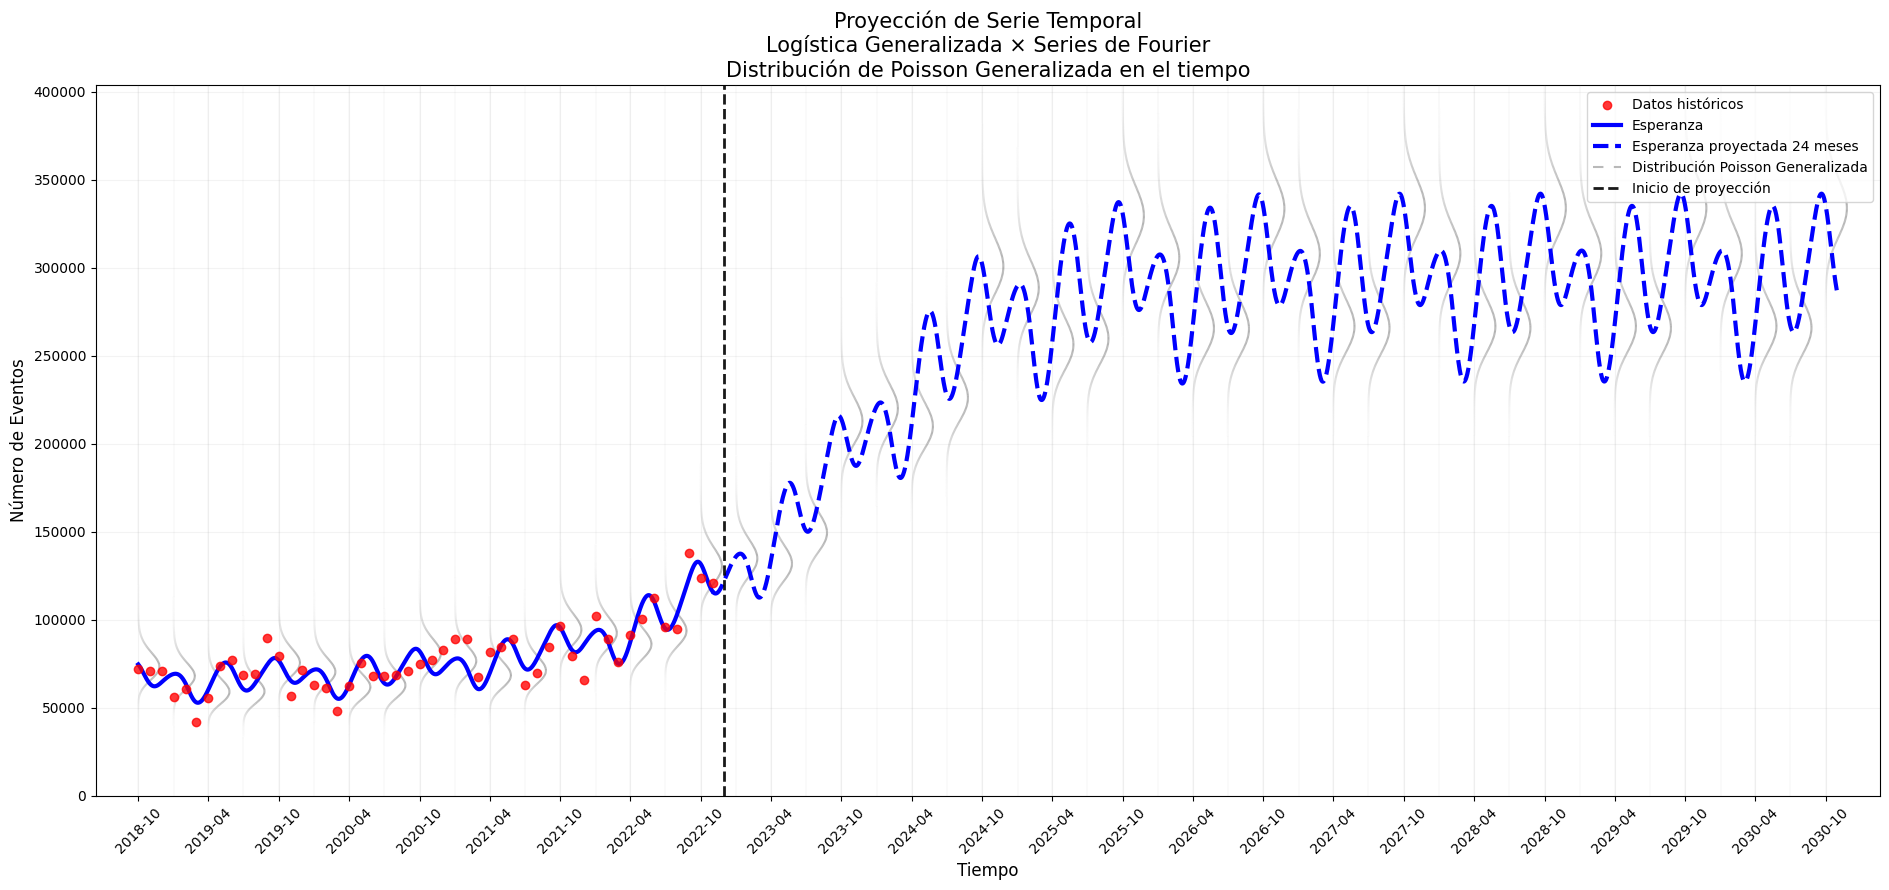

In [32]:
# ============================================================
# PLOT
# PROYECCIÓN DE SERIE TEMPORAL
# ============================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ============================================================
# 1. CONFIGURACIÓN DEL PLOT
# ============================================================

EPS_PLOT = 1e-12


# ------------------------------------------------------------
# Cada cuántos períodos mostrar una distribución
# ------------------------------------------------------------

PMF_CADA_N_PERIODOS = 3


# ------------------------------------------------------------
# Resolución de cada PMF
# ------------------------------------------------------------

PMF_MAX_PUNTOS = 600


# ------------------------------------------------------------
# Ancho horizontal máximo de la PMF
#
# La distribución se dibuja "acostada":
#
# eje Y = número de eventos k
# eje X = densidad relativa
# ------------------------------------------------------------

PMF_ANCHO_MAX_DIAS = 55.0


# ------------------------------------------------------------
# Apariencia
# ------------------------------------------------------------

PMF_LINEWIDTH = 1.5

PMF_LINESTYLE = (
    0,
    (5, 5)
)

PMF_ALPHA_MAX = 0.60
PMF_ALPHA_MIN = 0.04

PMF_ALPHA_BANDS = 30
PMF_ALPHA_DECAY_SIGMAS = 2.5


# ------------------------------------------------------------
# Cuánto espacio vertical adicional dejar
# ------------------------------------------------------------

Y_MARGIN_INFERIOR = 0.05
Y_MARGIN_SUPERIOR = 0.18


# ------------------------------------------------------------
# Percentil para evitar que un outlier aislado determine
# toda la escala vertical
# ------------------------------------------------------------

Y_PERCENTIL = 99.5


# ============================================================
# 2. LOG-PMF POISSON GENERALIZADA
# ============================================================

def gp_log_pmf_plot(
    k,
    mu,
    rho
):

    k = np.asarray(
        k,
        dtype=np.float64
    )

    mu = float(
        max(
            mu,
            EPS_PLOT
        )
    )

    rho = float(
        rho
    )

    if rho >= 1.0:

        raise ValueError(
            "rho debe ser menor que 1."
        )


    # --------------------------------------------------------
    # Parametrización utilizada:
    #
    # lambda = mu * (1-rho)
    #
    # por lo tanto:
    #
    # E[Y] = mu
    # Var[Y] = mu / (1-rho)^2
    # --------------------------------------------------------

    lam = (
        mu
        *
        (1.0 - rho)
    )

    lam = max(
        lam,
        EPS_PLOT
    )


    term = (
        lam
        +
        rho * k
    )


    logp = np.full_like(
        k,
        -np.inf,
        dtype=np.float64
    )


    # --------------------------------------------------------
    # Caso k = 0
    # --------------------------------------------------------

    mask_zero = (
        k == 0
    )

    logp[
        mask_zero
    ] = -lam


    # --------------------------------------------------------
    # Caso k > 0
    # --------------------------------------------------------

    mask_positive = (
        (k > 0)
        &
        (term > 0)
    )


    if np.any(
        mask_positive
    ):

        kk = k[
            mask_positive
        ]

        aa = term[
            mask_positive
        ]


        lgamma_k = np.array(
            [
                math.lgamma(
                    float(v) + 1.0
                )
                for v in kk
            ],
            dtype=np.float64
        )


        logp[
            mask_positive
        ] = (

            np.log(
                lam
            )

            +

            (kk - 1.0)
            *
            np.log(
                aa
            )

            -

            aa

            -

            lgamma_k
        )


    return logp


# ============================================================
# 3. PMF DENTRO DE UNA VENTANA VISIBLE
# ============================================================

def gp_pmf_visible_plot(
    mu,
    rho,
    y_min,
    y_max,
    max_points=PMF_MAX_PUNTOS
):

    mu = float(
        max(
            mu,
            EPS_PLOT
        )
    )

    rho = float(
        rho
    )


    if rho >= 1.0:

        raise ValueError(
            "rho debe ser menor que 1."
        )


    # --------------------------------------------------------
    # Desviación estándar teórica
    #
    # Puede ser gigantesca si rho -> 1.
    # La calculamos, pero NO dejamos que destruya la escala
    # visual del gráfico.
    # --------------------------------------------------------

    sigma = (
        np.sqrt(
            mu
        )
        /
        max(
            1.0 - rho,
            EPS_PLOT
        )
    )


    # --------------------------------------------------------
    # Soporte matemático permitido
    # --------------------------------------------------------

    lam = (
        mu
        *
        (1.0 - rho)
    )


    if rho < 0.0:

        k_max_teorico = (
            lam
            /
            (-rho)
        )

        k_max_teorico = int(
            np.floor(
                k_max_teorico
                -
                1e-10
            )
        )

        k_max_teorico = max(
            0,
            k_max_teorico
        )

    else:

        k_max_teorico = np.inf


    # --------------------------------------------------------
    # IMPORTANTE:
    #
    # Solo mostramos la parte de la distribución contenida
    # dentro de los límites útiles del gráfico.
    #
    # Esto NO modifica la distribución.
    # Solo modifica su visualización.
    # --------------------------------------------------------

    k_min = int(
        max(
            0,
            np.floor(
                y_min
            )
        )
    )


    k_max = int(
        max(
            k_min + 1,
            np.ceil(
                y_max
            )
        )
    )


    if np.isfinite(
        k_max_teorico
    ):

        k_max = min(
            k_max,
            int(
                k_max_teorico
            )
        )


    if k_max <= k_min:

        return (
            np.array([]),
            np.array([]),
            sigma
        )


    # --------------------------------------------------------
    # Construcción de la malla
    # --------------------------------------------------------

    cantidad = (
        k_max
        -
        k_min
        +
        1
    )


    if cantidad <= max_points:

        k = np.arange(
            k_min,
            k_max + 1,
            dtype=np.int64
        )

    else:

        k = np.unique(
            np.round(
                np.linspace(
                    k_min,
                    k_max,
                    max_points
                )
            ).astype(
                np.int64
            )
        )


        # Asegurar que mu aparezca si está dentro del rango

        if (
            mu >= k_min
            and
            mu <= k_max
        ):

            k = np.unique(
                np.concatenate(
                    [
                        k,

                        np.array(
                            [
                                int(
                                    round(
                                        mu
                                    )
                                )
                            ],
                            dtype=np.int64
                        )
                    ]
                )
            )


    # --------------------------------------------------------
    # PMF
    # --------------------------------------------------------

    logp = gp_log_pmf_plot(
        k=k,
        mu=mu,
        rho=rho
    )


    finite = np.isfinite(
        logp
    )


    k = k[
        finite
    ]

    logp = logp[
        finite
    ]


    if len(k) < 2:

        return (
            np.array([]),
            np.array([]),
            sigma
        )


    # --------------------------------------------------------
    # Normalización VISUAL
    #
    # máximo = 1
    #
    # No afecta al modelo estadístico.
    # --------------------------------------------------------

    logp = (
        logp
        -
        np.max(
            logp
        )
    )


    p = np.exp(
        logp
    )


    p = np.where(
        np.isfinite(
            p
        ),
        p,
        0.0
    )


    p_max = np.max(
        p
    )


    if p_max > 0.0:

        p = (
            p
            /
            p_max
        )


    return (
        k.astype(
            np.float64
        ),
        p.astype(
            np.float64
        ),
        sigma
    )


# ============================================================
# 4. DIBUJAR PMF CON DESVANECIMIENTO
# ============================================================

def plot_pmf_desvanecida(
    ax,
    x_dist,
    k_vals,
    p_vals,
    label=None,
    zorder=5
):

    if len(
        k_vals
    ) < 2:

        return


    # --------------------------------------------------------
    # Alpha en función de la altura relativa de la PMF.
    #
    # Cerca del máximo:
    # más visible.
    #
    # En las colas:
    # más transparente.
    # --------------------------------------------------------

    p_normalizada = np.asarray(
        p_vals,
        dtype=np.float64
    )


    alpha_objetivo = (
        PMF_ALPHA_MIN
        +
        (
            PMF_ALPHA_MAX
            -
            PMF_ALPHA_MIN
        )
        *
        (
            p_normalizada
            **
            0.45
        )
    )


    # --------------------------------------------------------
    # Entrada para la leyenda
    # --------------------------------------------------------

    if label is not None:

        ax.plot(
            [],
            [],
            color="gray",
            linewidth=PMF_LINEWIDTH,
            linestyle=PMF_LINESTYLE,
            alpha=0.55,
            label=label
        )


    # --------------------------------------------------------
    # Dibujamos pequeños segmentos con alpha variable
    # --------------------------------------------------------

    for j in range(
        len(k_vals) - 1
    ):

        alpha_segmento = float(
            0.5
            *
            (
                alpha_objetivo[j]
                +
                alpha_objetivo[j + 1]
            )
        )


        ax.plot(
            x_dist[
                j:j + 2
            ],
            k_vals[
                j:j + 2
            ],
            color="gray",
            linewidth=PMF_LINEWIDTH,
            linestyle=PMF_LINESTYLE,
            alpha=alpha_segmento,
            zorder=zorder,
            label="_nolegend_"
        )


# ============================================================
# 5. PREPARAR FECHAS
# ============================================================

fechas_all = pd.date_range(
    start=pd.Timestamp(
        fecha_inicio
    ),
    periods=len(
        mu_all
    ),
    freq="MS"
)


corte = pd.Timestamp(
    data[
        "PERIODO"
    ].max()
)


fecha_inicio_forecast = (
    corte
    +
    pd.offsets.MonthBegin(
        1
    )
)


# ============================================================
# 6. ÍNDICES DE LAS DISTRIBUCIONES
# ============================================================

indices_pmf = np.arange(
    0,
    len(mu_all),
    PMF_CADA_N_PERIODOS,
    dtype=int
)


# ============================================================
# 7. CALCULAR ESCALA VERTICAL RAZONABLE
# ============================================================

y_hist_validos = np.asarray(
    y_np,
    dtype=np.float64
)

y_hist_validos = y_hist_validos[
    np.isfinite(
        y_hist_validos
    )
]


mu_dense_validos = np.asarray(
    mu_dense,
    dtype=np.float64
)

mu_dense_validos = mu_dense_validos[
    np.isfinite(
        mu_dense_validos
    )
]


mu_all_validos = np.asarray(
    mu_all,
    dtype=np.float64
)

mu_all_validos = mu_all_validos[
    np.isfinite(
        mu_all_validos
    )
]


valores_escala = np.concatenate(
    [
        y_hist_validos,
        mu_dense_validos,
        mu_all_validos
    ]
)


# ------------------------------------------------------------
# Evitar que una observación anómala expanda exageradamente
# el gráfico
# ------------------------------------------------------------

y_ref_superior = np.percentile(
    valores_escala,
    Y_PERCENTIL
)


y_ref_superior = max(
    y_ref_superior,
    np.max(
        mu_dense_validos
    )
)


y_ref_inferior = min(
    0.0,
    np.min(
        valores_escala
    )
)


rango_base = max(
    y_ref_superior
    -
    y_ref_inferior,
    1.0
)


y_plot_min = (
    y_ref_inferior
    -
    Y_MARGIN_INFERIOR
    *
    rango_base
)


y_plot_max = (
    y_ref_superior
    +
    Y_MARGIN_SUPERIOR
    *
    rango_base
)


# Los conteos no necesitan mostrar demasiado bajo cero

if y_ref_inferior >= 0:

    y_plot_min = 0.0


# ============================================================
# 8. FIGURA
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        19,
        9
    )
)


# ============================================================
# 9. DATOS HISTÓRICOS
# ============================================================

ax.scatter(
    data[
        "PERIODO"
    ],
    y_np,
    s=36,
    color="red",
    alpha=0.78,
    label="Datos históricos",
    zorder=10
)


# ============================================================
# 10. ESPERANZA HISTÓRICA
# ============================================================

mask_hist = (
    t_dense
    <=
    T_HIST
)


ax.plot(
    fecha_dense_num[
        mask_hist
    ],
    mu_dense[
        mask_hist
    ],
    color="blue",
    linewidth=3.0,
    label="Esperanza",
    zorder=9
)


# ============================================================
# 11. ESPERANZA PROYECTADA
# ============================================================

mask_forecast = (
    t_dense
    >=
    T_HIST
)


ax.plot(
    fecha_dense_num[
        mask_forecast
    ],
    mu_dense[
        mask_forecast
    ],
    color="blue",
    linewidth=3.0,
    linestyle="--",
    label="Esperanza proyectada 24 meses",
    zorder=9
)


# ============================================================
# 12. DISTRIBUCIONES POISSON GENERALIZADA
# ============================================================

label_dist_usado = False


for i in indices_pmf:

    mu_i = float(
        mu_all[
            i
        ]
    )


    if not np.isfinite(
        mu_i
    ):

        continue


    fecha_i = fechas_all[
        i
    ]


    x0 = mdates.date2num(
        fecha_i
    )


    (
        k_vals,
        p_vals,
        sigma_i

    ) = gp_pmf_visible_plot(
        mu=mu_i,
        rho=rho_value,
        y_min=y_plot_min,
        y_max=y_plot_max
    )


    if len(
        k_vals
    ) < 2:

        continue


    # --------------------------------------------------------
    # Densidad hacia la derecha
    #
    # La anchura horizontal representa únicamente la
    # probabilidad relativa.
    # --------------------------------------------------------

    dx = (
        p_vals
        *
        PMF_ANCHO_MAX_DIAS
    )


    x_dist = (
        x0
        +
        dx
    )


    if not label_dist_usado:

        texto_label = (
            "Distribución Poisson Generalizada"
        )

        label_dist_usado = True

    else:

        texto_label = None


    plot_pmf_desvanecida(
        ax=ax,
        x_dist=x_dist,
        k_vals=k_vals,
        p_vals=p_vals,
        label=texto_label,
        zorder=5
    )


# ============================================================
# 13. INICIO DE PROYECCIÓN
# ============================================================

ax.axvline(
    fecha_inicio_forecast,
    color="black",
    linestyle="--",
    linewidth=2.0,
    alpha=0.90,
    label="Inicio de proyección",
    zorder=12
)


# ============================================================
# 14. LÍMITES VERTICALES
# ============================================================

ax.set_ylim(
    y_plot_min,
    y_plot_max
)


# ============================================================
# 15. LÍMITES HORIZONTALES
# ============================================================

fecha_min_plot = min(
    pd.Timestamp(
        data[
            "PERIODO"
        ].min()
    ),
    fechas_all[
        0
    ]
)


fecha_max_plot = max(
    fechas_all[
        -1
    ],
    fecha_inicio_forecast
)


margen_x = pd.Timedelta(
    days=110
)


ax.set_xlim(
    fecha_min_plot
    -
    margen_x,
    fecha_max_plot
    +
    margen_x
)


# ============================================================
# 16. TÍTULO Y EJES
# ============================================================

ax.set_title(
    "Proyección de Serie Temporal\n"
    "Logística Generalizada × Series de Fourier\n"
    "Distribución de Poisson Generalizada en el tiempo",
    fontsize=15
)


ax.set_xlabel(
    "Tiempo",
    fontsize=12
)


ax.set_ylabel(
    "Número de Eventos",
    fontsize=12
)


# ============================================================
# 17. GRILLA
# ============================================================

ax.grid(
    True,
    alpha=0.15
)


# ============================================================
# 18. FORMATO DE FECHAS
# ============================================================

ax.xaxis.set_major_locator(
    mdates.MonthLocator(
        interval=6
    )
)


ax.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%Y-%m"
    )
)


plt.xticks(
    rotation=45
)


# ============================================================
# 19. LEYENDA
# ============================================================

ax.legend(
    fontsize=10,
    loc="upper right",
    frameon=True
)


# ============================================================
# 20. INFORMACIÓN DE DISPERSIÓN
# ============================================================

sigma_medio = np.median(
    [
        np.sqrt(
            max(
                float(mu_all[i]),
                EPS_PLOT
            )
        )
        /
        max(
            1.0 - float(rho_value),
            EPS_PLOT
        )
        for i in indices_pmf
    ]
)


print(
    "\n"
    +
    "=" * 60
)

print(
    "INFORMACIÓN DEL PLOT"
)

print(
    f"rho = {float(rho_value):.8f}"
)

print(
    f"sigma mediana GP = {sigma_medio:.3f}"
)

print(
    f"Límite Y mostrado = [{y_plot_min:.3f}, {y_plot_max:.3f}]"
)

print(
    "Las colas de la Poisson Generalizada fuera de estos límites"
)

print(
    "no se muestran para no destruir la escala de la serie temporal."
)

print(
    "=" * 60
    +
    "\n"
)


# ============================================================
# 21. MOSTRAR
# ============================================================

plt.tight_layout()

plt.show()